# Descripción del problema

El siguiente ejemplo consiste en un Ambiente (Room). La temperatura de la habitación cambia debido a la temperatura externa ambiente (se asume de forma desconocida). La habitación cuenta con un equipo de Aire Acondicionado controlado por un Agente. El objetivo de este Agente es mantener la temperatura en 0 grados. El Aire Acondicionado puede cambiar la temperatura en 0, 1, 2 o 3 grados ya sea frío o calor.

# Ambiente

El ambiente (Room) está simulado por el siguiente código

In [ ]:
from room import Room

# Test Room

In [ ]:
env = Room()

In [ ]:
env.observation_space

In [ ]:
env.observation_space.sample()

In [ ]:
env.action_space

In [ ]:
env.action_space.sample()

In [ ]:
env.reset()

# Reflex Agent

Esta es la implementación de un Agente Reflejo Simple, que dada la observación (temperatura de la habitación), toma una acción de enfriar o calentar en 0, 1, 2 o 3 grados. El agente solo enfría o calienta si la temperatura difiere en más de 2 grados.

In [ ]:
from agent_reflex import AgentReflex

# Test Reflex

In [ ]:
agent = AgentReflex(env)

In [ ]:
obs = env.reset(seed=2)
print(f"Temperatura inicial de la sala: {obs}")
print(f"Temperatura externa (igual a la inicial después de un reset): {env.external_temp}")

In [ ]:
# observamos el comportamiento del agente durante 100 pasos
total_steps = 100
# para almacenar las temperaturas externas y las observadas por el agente
external_res = []
agent_res = []

In [ ]:
for i in range(0, total_steps):  
    
    # solamente para evaluar la evolución de la temperatura de la habitación con y sin agente
    # la temperatura de la habitación sin el agente es igual a la temperatura exterior
    
    external_temp = env.external_temp
    external_res.append(external_temp)
    
    # decisión y acción del agente
    
    prev_obs = obs
    action = agent.next_action(obs)
    obs = env.step(action)
    agent_res.append(obs)  
    
    print('Externa:', external_temp, '\n','Obs. anterior:', prev_obs, '-> Acción:', action, '-> Room:', obs)

# Métrica de Performance
Una posible métrica de performance, podría ser la temperatura media del ambiente con la acción del agente.

In [ ]:
import numpy as np
print("Temperatura media con el agente: ", np.mean(agent_res))
print("Temperatura media sin el agente: ", np.mean(external_res))

# Graficando los resultados

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [ ]:
# Calcular temperaturas medias
mean_agent_temp = np.mean(agent_res)
mean_external_temp = np.mean(external_res)

plt.figure(figsize=(10, 6))
plt.axhline(color='black', label='Temperatura ideal (0°)')    #Temperatura ideal
plt.plot(range(0, total_steps), agent_res, color='red', label='Con agente')     #Temperatura con el agente
plt.plot(range(0, total_steps), external_res, color='blue', label='Sin agente') #Temperatura sin agente

# Agregar líneas horizontales con las temperaturas medias
plt.axhline(y=mean_agent_temp, color='red', linestyle='--', alpha=0.7, 
            label=f'Media con agente: {mean_agent_temp:.2f}°C')
plt.axhline(y=mean_external_temp, color='blue', linestyle='--', alpha=0.7, 
            label=f'Media sin agente: {mean_external_temp:.2f}°C')

plt.title('Evolución de la Temperatura de la Habitación')
plt.xlabel('Pasos (steps)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Otra posible métrica de performance, es evaluar para cada instante de tiempo (step) cuanto difiere la temperatura obtenida de la objetivo=0. Esto se puede hacer con mean_squared_error o mean_absolute_error. 
Comparemos la métrica obtenida por el agente contra la métrica obtenida sin un agente:

In [ ]:
goal_temp = np.zeros(total_steps)
print("Variación media con el agente: ", mean_absolute_error(goal_temp, agent_res))
print("Variación media sin el agente: ", mean_absolute_error(goal_temp, external_res))

In [ ]:
# Calcular la variación (diferencia absoluta respecto al objetivo) en cada paso
agent_variation = np.abs(np.array(agent_res) - 0)
external_variation = np.abs(np.array(external_res) - 0)

# Calcular las variaciones medias
mean_agent_variation = mean_absolute_error(goal_temp, agent_res)
mean_external_variation = mean_absolute_error(goal_temp, external_res)

# Graficar la variación
plt.figure(figsize=(10, 6))
plt.plot(range(0, total_steps), agent_variation, color='red', label='Variación con agente')
plt.plot(range(0, total_steps), external_variation, color='blue', label='Variación sin agente')

# Agregar líneas horizontales con las variaciones medias
plt.axhline(y=mean_agent_variation, color='red', linestyle='--', alpha=0.7, 
            label=f'Media con agente: {mean_agent_variation:.2f}°C')
plt.axhline(y=mean_external_variation, color='blue', linestyle='--', alpha=0.7, 
            label=f'Media sin agente: {mean_external_variation:.2f}°C')

plt.title('Variación de la Temperatura respecto al Objetivo (0°C)')
plt.xlabel('Pasos (steps)')
plt.ylabel('Variación Absoluta (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ejercicio: Model (Goal / Utility) Based Agent 

Construir un Agente basado en un modelo. 
Esto es: 
    - Construir un modelo a mano, por ejemplo un grafo, con estados y transiciones [Ver figura].
    - Discretizar las observaciones devueltas por el ambiente mapeándolas a un estado.
    - Tomar una decisón basada en el estado.
    - Definir un objetivo y una utilidad

Por ejemplo, el Agente podría conocer un modelo que tiene 2 estados {Frío, Calor}
<img src="Modelo.png">


## Solución: Model-Based Goal/Utility Agent

El agente implementado mantiene un **estado interno** y un **modelo del mundo**.

### Estados discretos (extiende el grafo Frío/Calor del enunciado)
| Estado | Rango de temperatura |
|---|---|
| MUY_FRIO | temp < -9 |
| FRIO | -9 <= temp < -2 |
| COMODO | -2 <= temp <= 2 |
| CALOR | 2 < temp <= 9 |
| MUY_CALOR | temp > 9 |

### Modelo interno
El agente estima la **tendencia de temperatura externa** observando cómo cambió la temperatura descontando su propia acción:
```
tendencia_externa = (temp_actual - temp_anterior) - acción_propia
```

### Objetivo (Goal)
Mantener la temperatura en **0°C** (estado COMODO).

### Función de Utilidad
```
U(temp) = -|temp - 0|
```
Máxima utilidad en 0°C. Evalúa **todas las acciones posibles** y elige la que maximiza la utilidad de la temperatura *predicha*.

### Diferencia clave vs AgentReflex
- **AgentReflex**: reacciona al estado *actual* con reglas if-else fijas
- **AgentModel**: *predice* el estado siguiente usando el modelo y elige la acción óptima

In [19]:
from agent_model import AgentModel

In [20]:
# Inicializar el entorno y el agente modelo con la misma seed=2 para comparar
env_model = Room()
agent_model = AgentModel(env_model)

obs_model = env_model.reset(seed=2)
print(f'Temperatura inicial de la sala: {obs_model}')
print(f'Temperatura externa inicial: {env_model.external_temp}')

Temperatura inicial de la sala: -8.34
Temperatura externa inicial: -8.34


In [21]:
# Observamos el comportamiento del AgentModel durante 100 pasos
total_steps = 100
external_res_model = []
agent_model_res = []

for i in range(total_steps):
    external_temp = env_model.external_temp
    external_res_model.append(external_temp)

    prev_obs = obs_model
    action = agent_model.next_action(obs_model)
    obs_model = env_model.step(action)
    agent_model_res.append(obs_model)

    estado = agent_model._discretize(prev_obs)
    pred   = agent_model._predict_next_temp(prev_obs, action)
    print(f'Externa: {external_temp:6.2f} | Estado: {estado:10s} | Acción: {action:+d} | Predicho: {pred:6.2f} | Room: {obs_model:6.2f}')

Externa:  -8.34 | Estado: FRIO       | Acción: +3 | Predicho:  -5.34 | Room:  -5.34
Externa:  -8.34 | Estado: FRIO       | Acción: +3 | Predicho:  -2.34 | Room:  -0.49
Externa:  -6.49 | Estado: COMODO     | Acción: -1 | Predicho:   0.36 | Room:   0.43
Externa:  -4.57 | Estado: COMODO     | Acción: -2 | Predicho:   0.35 | Room:   0.40
Externa:  -2.60 | Estado: COMODO     | Acción: -2 | Predicho:   0.37 | Room:   0.39
Externa:  -0.61 | Estado: COMODO     | Acción: -2 | Predicho:   0.38 | Room:   0.39
Externa:   1.39 | Estado: COMODO     | Acción: -2 | Predicho:   0.39 | Room:   0.38
Externa:   3.38 | Estado: COMODO     | Acción: -2 | Predicho:   0.37 | Room:   0.33
Externa:   5.33 | Estado: COMODO     | Acción: -2 | Predicho:   0.28 | Room:   0.23
Externa:   7.23 | Estado: COMODO     | Acción: -2 | Predicho:   0.13 | Room:   0.05
Externa:   9.05 | Estado: COMODO     | Acción: -2 | Predicho:  -0.13 | Room:  -0.21
Externa:  10.79 | Estado: COMODO     | Acción: -2 | Predicho:  -0.47 | Room:

## Métricas de Performance: AgentModel vs AgentReflex vs Sin Agente

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error

goal_temp = np.zeros(total_steps)

mae_model  = mean_absolute_error(goal_temp, agent_model_res)
mae_reflex = mean_absolute_error(goal_temp, agent_res)
mae_ext    = mean_absolute_error(goal_temp, external_res_model)

print('=== Variación media respecto al objetivo (0°C) ===')
print(f'  AgentModel  (basado en modelo): {mae_model:.4f} °C')
print(f'  AgentReflex (reflejo simple):   {mae_reflex:.4f} °C')
print(f'  Sin agente  (temperatura ext):  {mae_ext:.4f} °C')
print()
print(f'Mejora AgentModel vs Sin agente:  {((mae_ext - mae_model) / mae_ext * 100):.1f}%')
print(f'Mejora AgentModel vs AgentReflex: {((mae_reflex - mae_model) / mae_reflex * 100):.1f}%')

=== Variación media respecto al objetivo (0°C) ===
  AgentModel  (basado en modelo): 0.3230 °C
  AgentReflex (reflejo simple):   3.8580 °C
  Sin agente  (temperatura ext):  12.3104 °C

Mejora AgentModel vs Sin agente:  97.4%
Mejora AgentModel vs AgentReflex: 91.6%


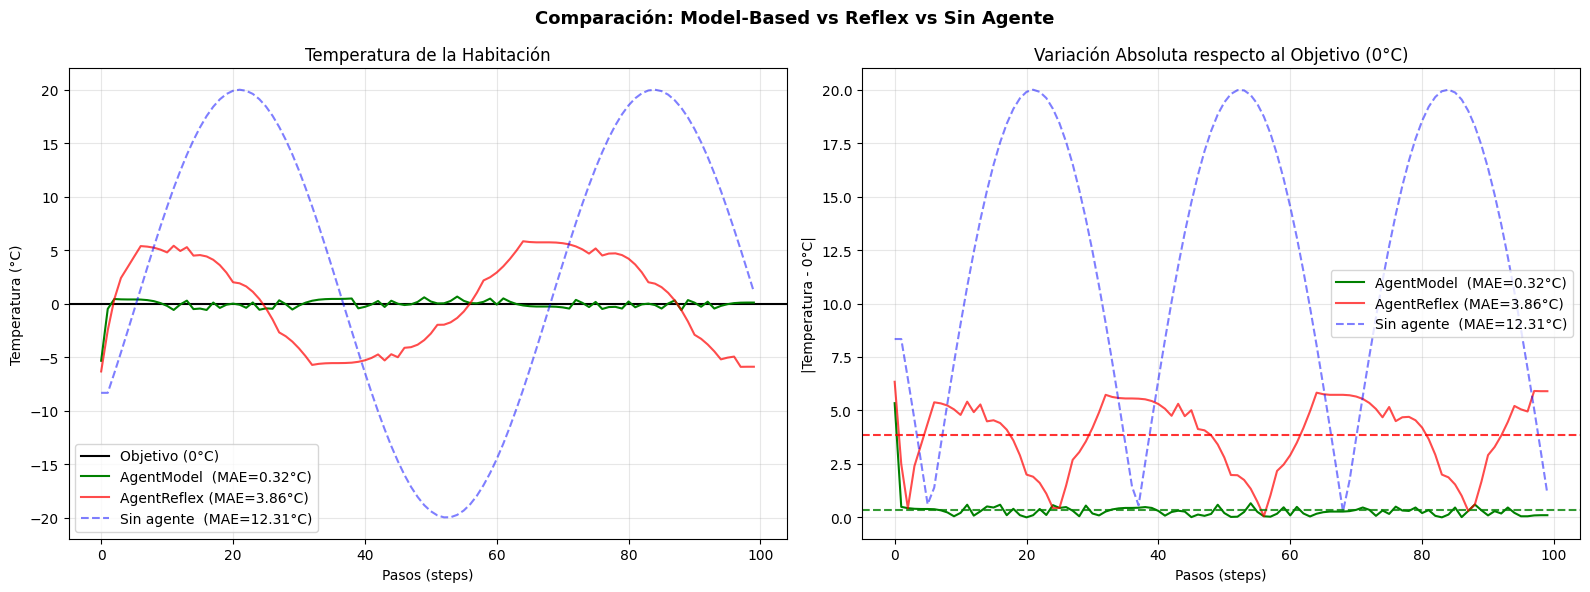

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Temperatura de la habitación ---
ax1 = axes[0]
ax1.axhline(color='black', linewidth=1.5, label='Objetivo (0°C)')
ax1.plot(range(total_steps), agent_model_res,    color='green', label=f'AgentModel  (MAE={mae_model:.2f}°C)')
ax1.plot(range(total_steps), agent_res,          color='red',   label=f'AgentReflex (MAE={mae_reflex:.2f}°C)', alpha=0.7)
ax1.plot(range(total_steps), external_res_model, color='blue',  label=f'Sin agente  (MAE={mae_ext:.2f}°C)', alpha=0.5, linestyle='--')
ax1.set_title('Temperatura de la Habitación')
ax1.set_xlabel('Pasos (steps)')
ax1.set_ylabel('Temperatura (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Variación absoluta respecto al objetivo ---
ax2 = axes[1]
ax2.plot(range(total_steps), np.abs(np.array(agent_model_res)),    color='green', label=f'AgentModel  (MAE={mae_model:.2f}°C)')
ax2.plot(range(total_steps), np.abs(np.array(agent_res)),          color='red',   label=f'AgentReflex (MAE={mae_reflex:.2f}°C)', alpha=0.7)
ax2.plot(range(total_steps), np.abs(np.array(external_res_model)), color='blue',  label=f'Sin agente  (MAE={mae_ext:.2f}°C)', alpha=0.5, linestyle='--')
ax2.axhline(y=mae_model,  color='green', linestyle='--', alpha=0.8)
ax2.axhline(y=mae_reflex, color='red',   linestyle='--', alpha=0.8)
ax2.set_title('Variación Absoluta respecto al Objetivo (0°C)')
ax2.set_xlabel('Pasos (steps)')
ax2.set_ylabel('|Temperatura - 0°C|')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Comparación: Model-Based vs Reflex vs Sin Agente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()